In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import sys
sys.path.insert(0,"../modules")
import romspy

In [2]:
ds = xr.open_dataset("../data/prsgrd_S0.nc", decode_times=False)
time = ds['ocean_time'].values / 86400
ubar_prsgrd_S0 = ds['ubar_prsgrd'].values[:,:-1,:]
vbar_prsgrd_S0 = ds['vbar_prsgrd'].values[:,:,:-1]
lon_u = ds['lon_u'].values[:-1,:]
lat_u = ds['lat_u'].values[:-1,:]
ds.close()

ds = xr.open_dataset("../data/prsgrd_S3.nc")
ubar_prsgrd_S3 = ds['ubar_prsgrd'].values[:,:-1,:]
vbar_prsgrd_S3 = ds['vbar_prsgrd'].values[:,:,:-1]
ds.close()

In [24]:
mag_prsgrd_S0 = np.sqrt(ubar_prsgrd_S0**2 + vbar_prsgrd_S0**2)
mag_prsgrd_S3 = np.sqrt(ubar_prsgrd_S3**2 + vbar_prsgrd_S3**2)
mag_prsgrd_S0[np.where(mag_prsgrd_S0 < 1e-12)] = np.nan 
dprsgrd = (mag_prsgrd_S3 - mag_prsgrd_S0) / (mag_prsgrd_S0) * 100
# dprsgrd[dprsgrd < -100] = np.nan
# dprsgrd[dprsgrd > 100] = np.nan

In [25]:
regime1 = "Jan-01-2017"
regime2 = "Jun-05-2017"
regime3 = "Sep-19-2017"
regime1 = romspy.str_datetime_2_ord(np.array([regime1]), "Nov-17-1858", "%b-%d-%Y")[0]
regime2 = romspy.str_datetime_2_ord(np.array([regime2]), "Nov-17-1858", "%b-%d-%Y")[0]
regime3 = romspy.str_datetime_2_ord(np.array([regime3]), "Nov-17-1858", "%b-%d-%Y")[0]
indx0 = np.where(time > regime1)[0][0]
indx1 = np.where(time > regime2)[0][0]
indx2 = np.where(time > regime3)[0][0]
dprsgrd1 = np.nanmean(dprsgrd[indx0:indx1,:,:],axis=0)
dprsgrd2 = np.nanmean(dprsgrd[indx1:indx2,:,:],axis=0)
dprsgrd3 = np.nanmean(dprsgrd[indx2:,:,:],axis=0)
print(romspy.bdy_mean("/orange/olabarrieta/scottleeyoung/papers/gulf_stream/data/GIS/SLEW_water-outline.shp", dprsgrd1, lon_u, lat_u))
print(romspy.bdy_mean("/orange/olabarrieta/scottleeyoung/papers/gulf_stream/data/GIS/SLEW_water-outline.shp", dprsgrd2, lon_u, lat_u))
print(romspy.bdy_mean("/orange/olabarrieta/scottleeyoung/papers/gulf_stream/data/GIS/SLEW_water-outline.shp", dprsgrd3, lon_u, lat_u))

/scratch/local/18391195/ipykernel_935861/3004172790.py:10: RuntimeWarning: Mean of empty slice
  dprsgrd1 = np.nanmean(dprsgrd[indx0:indx1,:,:],axis=0)
/scratch/local/18391195/ipykernel_935861/3004172790.py:11: RuntimeWarning: Mean of empty slice
  dprsgrd2 = np.nanmean(dprsgrd[indx1:indx2,:,:],axis=0)
/scratch/local/18391195/ipykernel_935861/3004172790.py:12: RuntimeWarning: Mean of empty slice
  dprsgrd3 = np.nanmean(dprsgrd[indx2:,:,:],axis=0)


20.764689089507282
20.758943580499558
19.87244822661412


/scratch/local/18391195/ipykernel_935861/2277349525.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


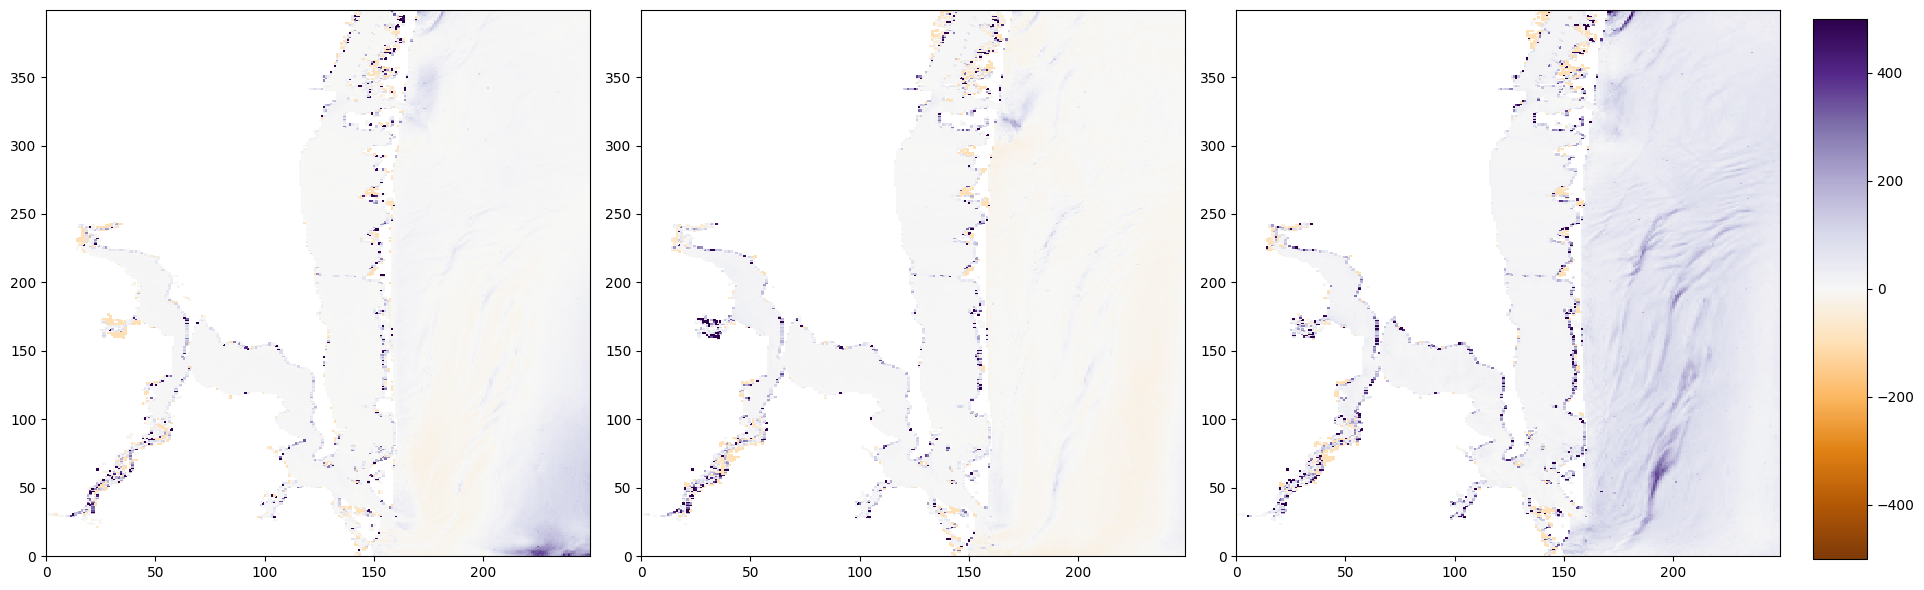

In [26]:
fig, ax = plt.subplots(figsize=(18, 6), ncols=3)

im = ax[0].pcolor(dprsgrd1, vmin=-500, vmax=500, cmap='PuOr')
ax[1].pcolor(dprsgrd2, vmin=-500, vmax=500, cmap='PuOr')
ax[2].pcolor(dprsgrd3, vmin=-500, vmax=500, cmap='PuOr')

cbarax = fig.add_axes([1.01, 0.06, 0.03, 0.9])
cbar = fig.colorbar(im, cax=cbarax)

fig.tight_layout()

In [81]:
np.nanmax(dprsgrd3), np.nanmin(dprsgrd3)

(87797.23096145566, -100.0)